# Create a predictive maintenance model for a delivery company

#### Import necessary packages

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.2f}'.format)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from imblearn.over_sampling import SMOTE

from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

#### Import data 

In [5]:
df = pd.read_csv("failure.csv")

### Exploratory Data Analysis

In [7]:
df.head()

,date,device,failure,attribute1,attribute2,attribute3,attribute4,attribute5,attribute6,attribute7,attribute8,attribute9
0,2015-01-01,S1F01085,0,215630672,56,0,52,6,407438,0,0,7
1,2015-01-01,S1F0166B,0,61370680,0,3,0,6,403174,0,0,0
2,2015-01-01,S1F01E6Y,0,173295968,0,0,0,12,237394,0,0,0
3,2015-01-01,S1F01JE0,0,79694024,0,0,0,6,410186,0,0,0
4,2015-01-01,S1F01R2B,0,135970480,0,0,0,15,313173,0,0,3


In [8]:
df.describe()

,failure,attribute1,attribute2,attribute3,attribute4,attribute5,attribute6,attribute7,attribute8,attribute9
count,124494.00,124494.00,124494.00,124494.00,124494.00,124494.00,124494.00,124494.00,124494.00,124494.00
mean,0.00,122386752.67,159.48,9.94,1.74,14.22,260172.86,0.29,0.29,12.45
std,0.03,70459597.49,2179.66,185.75,22.91,15.94,99151.01,7.44,7.44,191.43
min,0.00,0.00,0.00,0.00,0.00,1.00,8.00,0.00,0.00,0.00
25%,0.00,61276754.00,0.00,0.00,0.00,8.00,221452.00,0.00,0.00,0.00
50%,0.00,122795744.00,0.00,0.00,0.00,10.00,249799.50,0.00,0.00,0.00
75%,0.00,183308370.00,0.00,0.00,0.00,12.00,310266.00,0.00,0.00,0.00
max,1.00,244140480.00,64968.00,24929.00,1666.00,98.00,689161.00,832.00,832.00,18701.00


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124494 entries, 0 to 124493
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   date        124494 non-null  object
 1   device      124494 non-null  object
 2   failure     124494 non-null  int64 
 3   attribute1  124494 non-null  int64 
 4   attribute2  124494 non-null  int64 
 5   attribute3  124494 non-null  int64 
 6   attribute4  124494 non-null  int64 
 7   attribute5  124494 non-null  int64 
 8   attribute6  124494 non-null  int64 
 9   attribute7  124494 non-null  int64 
 10  attribute8  124494 non-null  int64 
 11  attribute9  124494 non-null  int64 
dtypes: int64(10), object(2)
memory usage: 11.4+ MB


In [10]:
df.sample(10)

,date,device,failure,attribute1,attribute2,attribute3,attribute4,attribute5,attribute6,attribute7,attribute8,attribute9
108738,2015-08-01,S1F0KYCR,0,172426456,0,0,0,10,291366,0,0,0
60870,2015-03-25,S1F10PED,0,231110728,0,0,0,5,214347,0,0,0
103837,2015-07-17,W1F0FYLJ,0,90572512,0,4,0,98,248948,0,0,20
14578,2015-01-17,S1F11A9R,0,231800992,0,0,0,23,244787,0,0,0
106639,2015-07-25,Z1F0KSLS,0,146434176,0,0,0,66,251617,0,0,0
14771,2015-01-17,W1F0WKMJ,0,195336032,0,34,0,6,260170,0,0,8
68750,2015-04-10,W1F0WZ0P,0,103938984,0,0,0,11,220224,0,0,0
52605,2015-03-12,Z1F1A1HH,0,123354184,0,0,0,7,228073,0,0,0
76044,2015-04-30,S1F0GPFZ,0,43875784,0,0,0,9,251894,0,0,0
50124,2015-03-09,S1F10V1N,0,171833048,0,0,0,10,421321,0,0,0


In [11]:
df.corr(numeric_only=True)

,failure,attribute1,attribute2,attribute3,attribute4,attribute5,attribute6,attribute7,attribute8,attribute9
failure,1.00,0.00,0.05,-0.00,0.07,0.00,-0.00,0.12,0.12,0.00
attribute1,0.00,1.00,-0.00,0.00,0.00,-0.00,-0.00,0.00,0.00,0.00
attribute2,0.05,-0.00,1.00,-0.00,0.15,-0.01,-0.03,0.14,0.14,-0.00
attribute3,-0.00,0.00,-0.00,1.00,0.10,-0.01,0.01,-0.00,-0.00,0.53
attribute4,0.07,0.00,0.15,0.10,1.00,-0.01,0.02,0.05,0.05,0.04
attribute5,0.00,-0.00,-0.01,-0.01,-0.01,1.00,-0.02,-0.01,-0.01,0.01
attribute6,-0.00,-0.00,-0.03,0.01,0.02,-0.02,1.00,-0.01,-0.01,0.02
attribute7,0.12,0.00,0.14,-0.00,0.05,-0.01,-0.01,1.00,1.00,0.01
attribute8,0.12,0.00,0.14,-0.00,0.05,-0.01,-0.01,1.00,1.00,0.01
attribute9,0.00,0.00,-0.00,0.53,0.04,0.01,0.02,0.01,0.01,1.00


In [12]:
df.drop(columns=["attribute8"], inplace=True)  # att7 ve att8 arasında çok yüksek koorelasyon olduğu için 1 ini kaldırıyoruz

In [13]:
df.isnull().sum()

date          0
device        0
failure       0
attribute1    0
attribute2    0
attribute3    0
attribute4    0
attribute5    0
attribute6    0
attribute7    0
attribute9    0
dtype: int64

In [14]:
columns = list(df.columns)

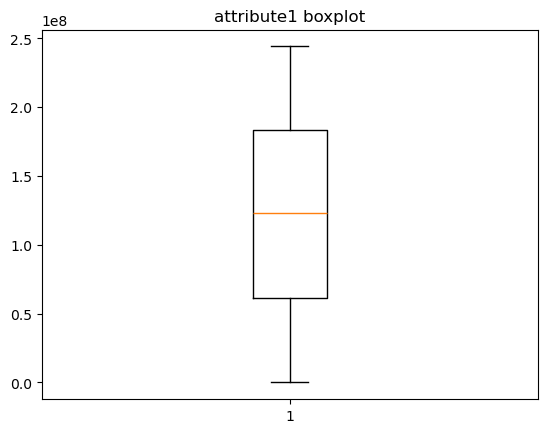

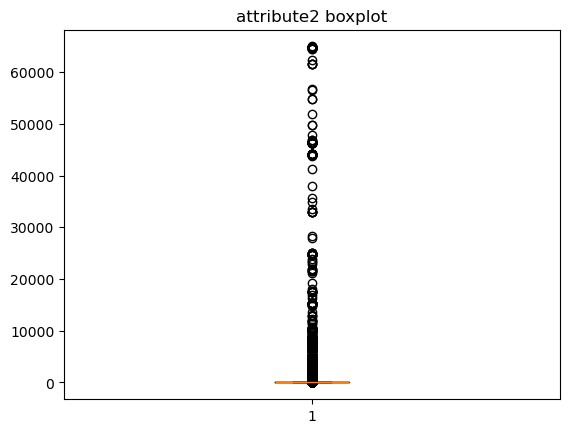

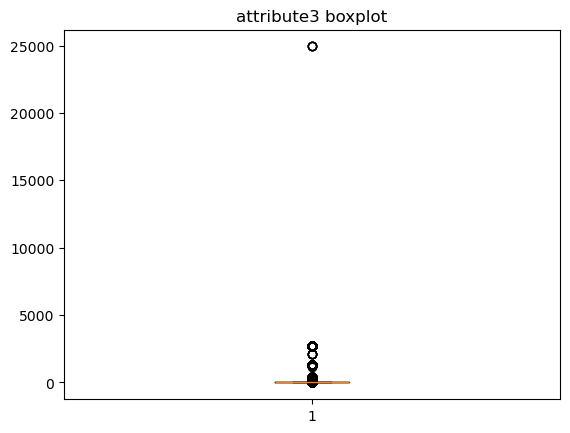

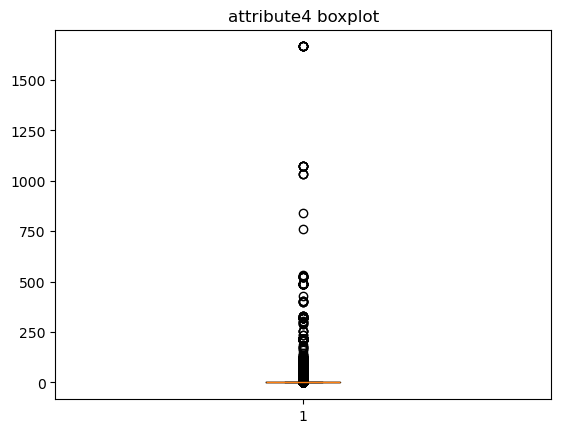

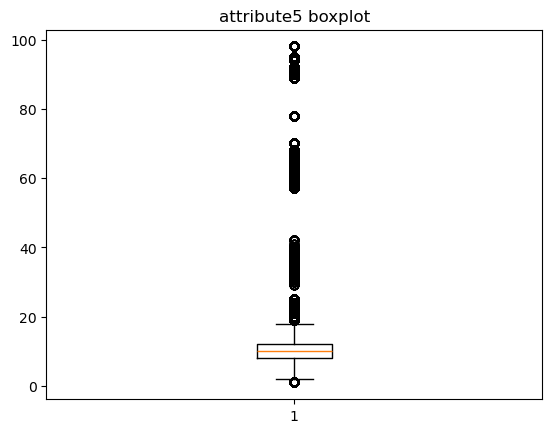

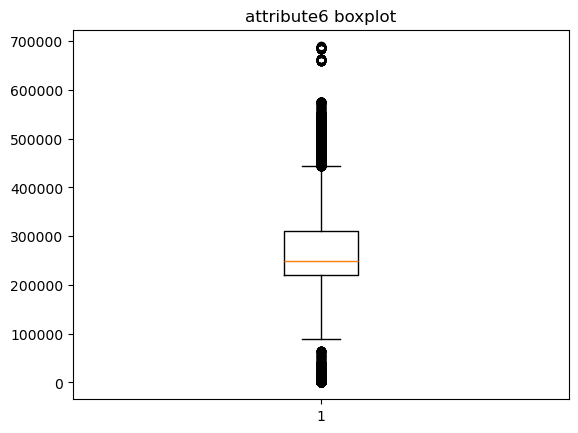

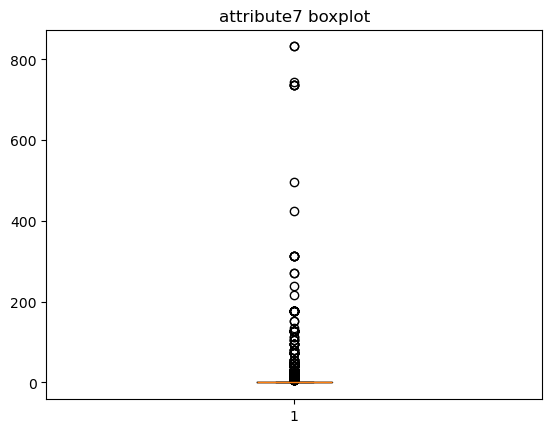

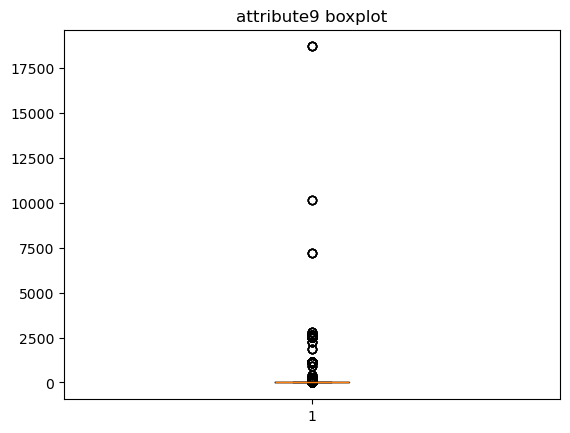

In [15]:
for i in columns[3:]:
    plt.boxplot(df[i])
    plt.title(f'{i} boxplot')
    plt.show()


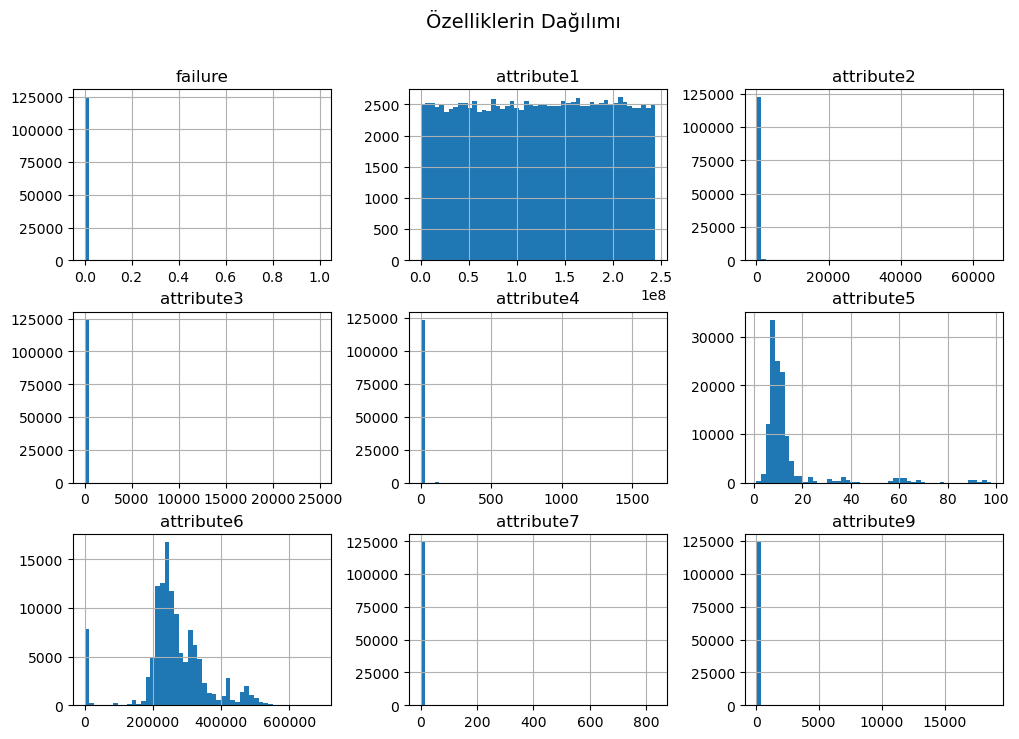

In [16]:
# Sadece sayısal sütunları seçelim (date ve device hariç)
numeric_columns = df.select_dtypes(include=['number']).columns

# Histogram çizelim
df[numeric_columns].hist(figsize=(12, 8), bins=50)
plt.suptitle("Özelliklerin Dağılımı", fontsize=14)
plt.show()

In [17]:
failure_dist = df["failure"].value_counts(normalize=True) * 100

In [18]:
failure_dist

failure
0   99.91
1    0.09
Name: proportion, dtype: float64

In [19]:
# Her sütundaki sıfır oranı
zero_perc = (df==0).sum() / len(df)*100

In [20]:
zero_perc

date          0.00
device        0.00
failure      99.91
attribute1    0.01
attribute2   94.87
attribute3   92.66
attribute4   92.50
attribute5    0.00
attribute6    0.00
attribute7   98.83
attribute9   78.20
dtype: float64

In [21]:
# Sıfır oranı yüksek olan sütunları belirleyelim 
high_zero_columns = zero_perc[zero_perc > 80]

In [22]:
high_zero_columns

failure      99.91
attribute2   94.87
attribute3   92.66
attribute4   92.50
attribute7   98.83
dtype: float64

In [23]:
df = df.drop(columns=["date","device"]) # önemsiz sütunları kaldırıyoruz

In [24]:
# Seyrek değişkenleri (0) binary formata çeviriyoruz, 0 olmayan değerler 1 olacak
sparse = high_zero_columns.index.tolist()
for col in sparse:
    df[col] = (df[col] > 0).astype(int)

In [25]:
df

,failure,attribute1,attribute2,attribute3,attribute4,attribute5,attribute6,attribute7,attribute9
0,0,215630672,1,0,1,6,407438,0,7
1,0,61370680,0,1,0,6,403174,0,0
2,0,173295968,0,0,0,12,237394,0,0
3,0,79694024,0,0,0,6,410186,0,0
4,0,135970480,0,0,0,15,313173,0,3
...,...,...,...,...,...,...,...,...,...
124489,0,18310224,0,0,0,10,353705,1,0
124490,0,172556680,1,1,1,11,332792,0,13
124491,0,19029120,1,0,0,11,350410,0,0
124492,0,226953408,0,0,0,12,358980,0,0


In [26]:
x = df.drop(columns=["failure"])
y = df["failure"]

### Modelling

In [28]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.2, random_state=42, stratify=y)

In [29]:
#Normalizasyon
scaler = MinMaxScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [92]:
x_train_scaled

array([[3.54874407e-01, 0.00000000e+00, 0.00000000e+00, ...,
        3.55977555e-01, 0.00000000e+00, 0.00000000e+00],
       [1.75728597e-01, 0.00000000e+00, 0.00000000e+00, ...,
        6.52975464e-05, 0.00000000e+00, 0.00000000e+00],
       [4.89680204e-01, 1.00000000e+00, 0.00000000e+00, ...,
        3.91347059e-01, 0.00000000e+00, 0.00000000e+00],
       ...,
       [1.62548448e-01, 0.00000000e+00, 0.00000000e+00, ...,
        3.61717935e-01, 0.00000000e+00, 5.34730763e-05],
       [8.16468158e-01, 1.00000000e+00, 0.00000000e+00, ...,
        3.77006267e-01, 0.00000000e+00, 0.00000000e+00],
       [8.45649816e-01, 0.00000000e+00, 0.00000000e+00, ...,
        3.11792882e-01, 0.00000000e+00, 0.00000000e+00]])

In [31]:
x_train = pd.DataFrame(x_train_scaled, columns=x.columns)
x_test = pd.DataFrame(x_test_scaled, columns=x.columns)

In [32]:
x_train

,attribute1,attribute2,attribute3,attribute4,attribute5,attribute6,attribute7,attribute9
0,0.35,0.00,0.00,0.00,0.59,0.36,0.00,0.00
1,0.18,0.00,0.00,0.00,0.15,0.00,0.00,0.00
2,0.49,1.00,0.00,0.00,0.09,0.39,0.00,0.00
3,0.59,0.00,0.00,0.00,0.08,0.29,0.00,0.00
4,0.16,0.00,0.00,0.00,0.07,0.53,0.00,0.00
...,...,...,...,...,...,...,...,...
99590,0.73,0.00,0.00,0.00,0.11,0.41,0.00,0.00
99591,0.95,0.00,0.00,0.00,0.05,0.47,0.00,0.00
99592,0.16,0.00,0.00,1.00,0.58,0.36,0.00,0.00
99593,0.82,1.00,0.00,0.00,0.07,0.38,0.00,0.00


In [33]:
# SMOTE ile azınlık sınıfı artırıyoruz
smote = SMOTE(sampling_strategy=.1, random_state=42)

In [34]:
x_train_resampled , y_train_resampled = smote.fit_resample(x_train, y_train)

In [35]:
y_train_resampled.value_counts()

failure
0    99510
1     9951
Name: count, dtype: int64

### Logistic Regression

In [37]:
LR = LogisticRegression(class_weight="balanced", random_state=42, max_iter=1000)

In [38]:
LR.fit(x_train_resampled, y_train_resampled)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [39]:
LR_pred = LR.predict(x_test)

In [40]:
accuracy_score(LR_pred,y_test)

0.8926864532712158

In [41]:
confusion_matrix(LR_pred,y_test)

array([[22211,     5],
       [ 2667,    16]], dtype=int64)

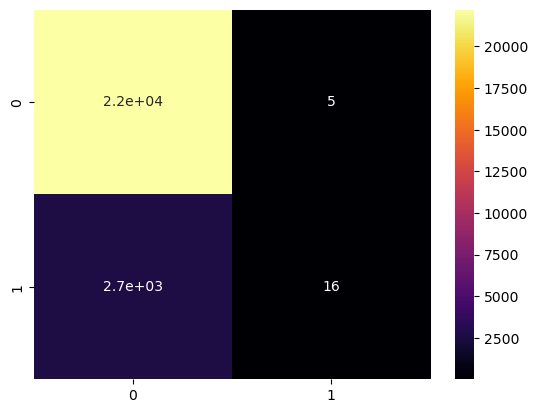

In [42]:
sns.heatmap(confusion_matrix(LR_pred,y_test), annot=True, cmap="inferno");

In [43]:
print(classification_report(LR_pred,y_test))

              precision    recall  f1-score   support

           0       0.89      1.00      0.94     22216
           1       0.76      0.01      0.01      2683

    accuracy                           0.89     24899
   macro avg       0.83      0.50      0.48     24899
weighted avg       0.88      0.89      0.84     24899



### Random Forest

In [45]:
RF = RandomForestClassifier(n_estimators=100, random_state=42)

accuracy score : 0.9984336720350215

---------Classification Report-----------

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     24879
           1       0.05      0.05      0.05        20

    accuracy                           1.00     24899
   macro avg       0.52      0.52      0.52     24899
weighted avg       1.00      1.00      1.00     24899

---------Confusion Matrix and Heat Map----------------

 CONFUSION MATRIX : 

 [[24859    20]
 [   19     1]]
       
Axes(0.125,0.11;0.62x0.77)


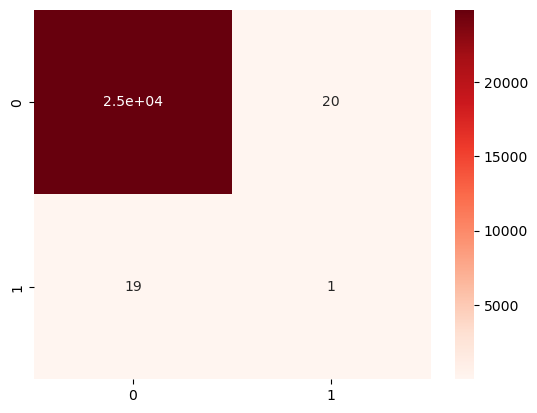

In [46]:
RF.fit(x_train_resampled, y_train_resampled)
RF_pred = RF.predict(x_test)
print(f'accuracy score : {accuracy_score(RF_pred,y_test)}\n')
print("---------Classification Report-----------\n")
print(classification_report(RF_pred,y_test))
print("---------Confusion Matrix and Heat Map----------------\n")
print(f" CONFUSION MATRIX : \n\n {confusion_matrix(RF_pred,y_test)}\n       ")
print(sns.heatmap(confusion_matrix(RF_pred,y_test), annot=True, cmap="Reds"));

### XGBOOST

In [48]:
XGB = xgb.XGBClassifier(eval_metric="logloss", scale_pos_weight=99, random_state=42)

accuracy score : 0.9848588296718743

---------Classification Report-----------

              precision    recall  f1-score   support

           0       0.99      1.00      0.99     24539
           1       0.10      0.01      0.01       360

    accuracy                           0.98     24899
   macro avg       0.54      0.50      0.50     24899
weighted avg       0.97      0.98      0.98     24899

---------Confusion Matrix and Heat Map----------------

 CONFUSION MATRIX : 

 [[24520    19]
 [  358     2]]
       
Axes(0.125,0.11;0.62x0.77)


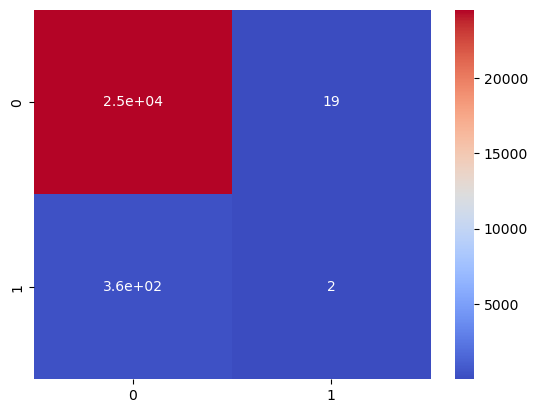

In [49]:
XGB.fit(x_train_resampled, y_train_resampled)
XGB_pred = XGB.predict(x_test)
print(f'accuracy score : {accuracy_score(XGB_pred,y_test)}\n')
print("---------Classification Report-----------\n")
print(classification_report(XGB_pred,y_test))
print("---------Confusion Matrix and Heat Map----------------\n")
print(f" CONFUSION MATRIX : \n\n {confusion_matrix(XGB_pred,y_test)}\n       ")
print(sns.heatmap(confusion_matrix(XGB_pred,y_test), annot=True, cmap="coolwarm"));